# 06b — Recommendations & Success Criteria (docs 12, 14)

**Phase 6, part B — the finale.** Validated, named segments + each customer's predicted CLV → the
**segment × CLV action grid**, one clear action per segment, and budget that follows **value at
stake** (not headcount). Then the honest **success criteria** and the final customer-level
deliverable.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import segments, utils

sns.set_theme(style="whitegrid")
PHASE = "06b_recommendations"
ORDER = segments.SEGMENT_ORDER
NAMES = segments.SEGMENT_NAMES

In [2]:
df = segments.assign_customer_actions(segments.load_segment_panel())
vas = segments.value_at_stake(df)
print("VALUE AT STAKE per segment:\n",
      vas[["persona", "action", "headcount_pct", "rev_share_pct", "clv_share_pct"]].to_string())

VALUE AT STAKE per segment:
               persona    action  headcount_pct  rev_share_pct  clv_share_pct
segment                                                                     
R0          Champions   Protect           26.7           80.7           71.7
R1             Rising      Grow           21.0            7.9           16.4
R2            At-Risk  Win-back           24.7            8.1            5.7
one-timer  One-Timers   Convert           27.6            3.2            6.2


## Spend follows VALUE AT STAKE, not headcount (doc 14 §3)

The segments are ~equal in headcount (21–28%) but wildly unequal in value: **Champions are 27% of
customers but 81% of revenue / 72% of future value.** Budgeting by headcount would pour money into
the ~28% One-Timers who are barely worth anything. Money on the line is the right lens.

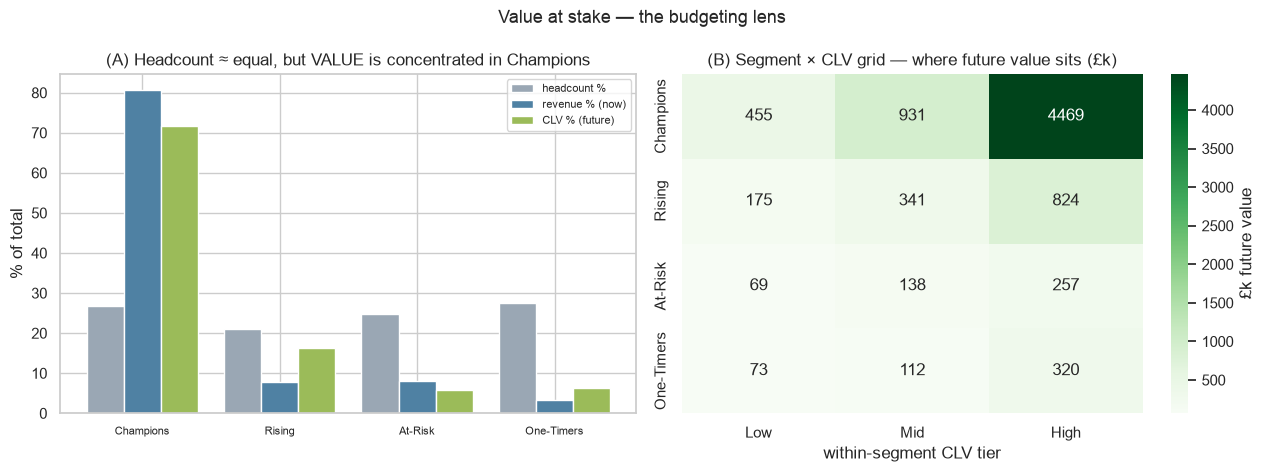

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(4); w = 0.27
ax[0].bar(x - w, vas.loc[ORDER, "headcount_pct"], w, label="headcount %", color="#9aa7b4")
ax[0].bar(x, vas.loc[ORDER, "rev_share_pct"], w, label="revenue % (now)", color="#4f81a3")
ax[0].bar(x + w, vas.loc[ORDER, "clv_share_pct"], w, label="CLV % (future)", color="#9bbb59")
ax[0].set_xticks(x); ax[0].set_xticklabels([NAMES[s] for s in ORDER], fontsize=8)
ax[0].set_ylabel("% of total"); ax[0].legend(fontsize=8)
ax[0].set_title("(A) Headcount ≈ equal, but VALUE is concentrated in Champions")

# (B) segment × CLV-tier grid — total £CLV (value at stake) per cell.
grid = segments.segment_clv_grid(df, value="clv", aggfunc="sum").loc[ORDER, ["Low", "Mid", "High"]] / 1000
sns.heatmap(grid, annot=True, fmt=".0f", cmap="Greens", cbar_kws={"label": "£k future value"},
            ax=ax[1], yticklabels=[NAMES[s] for s in ORDER])
ax[1].set_title("(B) Segment × CLV grid — where future value sits (£k)")
ax[1].set_xlabel("within-segment CLV tier"); ax[1].set_ylabel("")
fig.suptitle("Value at stake — the budgeting lens", fontsize=13)
fig.tight_layout()
fig.savefig(utils.figure_path(PHASE, "value_at_stake.png"), dpi=150, bbox_inches="tight")
plt.show()

## The action grid (doc 14 §3)

One segment, one clear action; the within-segment CLV tier sets the *intensity*.

In [4]:
action_grid = pd.DataFrame({
    "Persona": [NAMES[s] for s in ORDER],
    "Action": [segments.SEGMENT_ACTIONS[s] for s in ORDER],
    "Why": [
        "recent · frequent · high-spend · 81% of revenue — retain, VIP, do NOT discount",
        "recent · newest · CLV share 2× revenue — nurture into Champions (highest upside)",
        "established but lapsed ~1yr · P(alive) 0.80 — reactivate the HIGH-CLV lapsers first",
        "single purchase · 3% of revenue — low-cost 2nd-purchase nudge; do not overspend",
    ],
    "Headcount %": vas.loc[ORDER, "headcount_pct"].values,
    "Revenue %": vas.loc[ORDER, "rev_share_pct"].values,
    "CLV %": vas.loc[ORDER, "clv_share_pct"].values,
})
print(action_grid.to_string(index=False))

   Persona   Action                                                                                 Why  Headcount %  Revenue %  CLV %
 Champions  Protect      recent · frequent · high-spend · 81% of revenue — retain, VIP, do NOT discount         26.7       80.7   71.7
    Rising     Grow    recent · newest · CLV share 2× revenue — nurture into Champions (highest upside)         21.0        7.9   16.4
   At-Risk Win-back established but lapsed ~1yr · P(alive) 0.80 — reactivate the HIGH-CLV lapsers first         24.7        8.1    5.7
One-Timers  Convert     single purchase · 3% of revenue — low-cost 2nd-purchase nudge; do not overspend         27.6        3.2    6.2


**Within-segment refinement (the grid):** the single richest cell is **High-CLV Champions (~£4.5M)**
→ protect hardest. For **At-Risk**, the **High-CLV** cell (~£0.26M) is the prime win-back target — a
high-value customer slipping is the best place to spend a retention pound (doc 12); the Low-CLV
At-Risk cell (~£0.07M) is not worth chasing.

## Optional ROI framing — HYPOTHETICAL (doc 14 §3)

We have **no campaign-response data**, so this is illustrative reasoning only, stated out loud.

In [5]:
high_clv_atrisk = df.query("segment == 'R2' and clv_tier == 'High'")["clv"].sum()
for conv in (0.05, 0.10, 0.20):
    print(f"  IF a win-back converts {conv:.0%} of High-CLV At-Risk → recovers ~£{conv*high_clv_atrisk:,.0f} "
          f"of predicted CLV (HYPOTHETICAL — no response data).")

  IF a win-back converts 5% of High-CLV At-Risk → recovers ~£12,846 of predicted CLV (HYPOTHETICAL — no response data).
  IF a win-back converts 10% of High-CLV At-Risk → recovers ~£25,692 of predicted CLV (HYPOTHETICAL — no response data).
  IF a win-back converts 20% of High-CLV At-Risk → recovers ~£51,385 of predicted CLV (HYPOTHETICAL — no response data).


## What 'good' looks like — success criteria (doc 14 §4)

Unsupervised → there is no accuracy score, so we defined success deliberately, and met it:

1. **Robust** — only the segments that survive bootstrap resampling (Jaccard ≈ 0.79) were kept.
2. **Differ on external variables** — segments separate strongly on **predicted CLV (η²≈0.62)**, a
   variable the clustering never saw (the free cross-validation).
3. **Honest about the data** — we reported the **continuum** (moderate cross-method ARI), the CLV
   **seasonality** limitation, the **geography null**, and the **one-timer degeneracy** — nothing
   buried.
4. **Validated & compared** — three clustering methods, three validation tiers, MAP-vs-MCMC, rule-RFM
   agreement.
5. **Actionable** — 4 personas, one action each, budget by value at stake, a customer-level table.

The modest-but-honest result ("the data is largely a continuum; 3 robust segments + one-timers that
differ on CLV — here is each profile, action, and value at stake") is the *successful* one (doc 14).

## Final deliverable — the customer-level table

In [6]:
deliverable = df[["persona", "segment", "Recency", "Frequency", "Monetary", "Tenure",
                  "p_alive", "clv", "clv_tier", "action"]].copy()
deliverable.to_parquet(utils.DATA_PROCESSED / "customer_segments_actions.parquet")
print("saved customer_segments_actions.parquet:", deliverable.shape)
print(deliverable.head(6).round(2).to_string())

saved customer_segments_actions.parquet: (5852, 10)
                persona    segment  Recency  Frequency  Monetary  Tenure  p_alive       clv clv_tier   action
Customer ID                                                                                                  
12346         Champions         R0      347          3  77352.96     669     0.82  25693.78     High  Protect
12347         Champions         R0       24          8   5633.32     426     0.97   3542.53     High  Protect
12348            Rising         R1       97          5   1658.40     460     0.94   1064.40      Mid     Grow
12349         Champions         R0       40          3   3678.69     611     0.96   1279.66      Low  Protect
12350        One-Timers  one-timer      332          1    294.40     332     1.00    230.07      Mid  Convert
12351        One-Timers  one-timer      397          1    300.93     397     1.00    198.35      Mid  Convert


---
**Project complete.** From 1M+ raw transactions → cleaned data → behavioural features → **3 validated
repeat-buyer segments + one-timers**, each with predicted **CLV (with uncertainty)** and a clear
**action**, budgeted by **value at stake**. The headline: behaviour is a continuum, but a useful
4-way discretisation that (independently) differs on future value — Champions to protect, Rising to
grow, At-Risk to win back, One-Timers to convert cheaply.